In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [25]:
def show_image(image, title=None):
    """Display an image using matplotlib."""
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(image)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()
    
def calcular_dft_centrada(imagen_grayscale):
    dft = cv2.dft(np.float32(imagen_grayscale), flags=cv2.DFT_COMPLEX_OUTPUT)
    return np.fft.fftshift(dft)
    
def mostrar_frecuencias(imagen_grayscale, dft_shift, mostrar_fase=False, titulo=''):
    real = dft_shift[:, :, 0]
    imag = dft_shift[:, :, 1]
    magnitud = 20 * np.log1p(np.sqrt(real**2 + imag**2))

    if mostrar_fase:
        fase = np.angle(real + 1j * imag)

    n_subplots = 3 if mostrar_fase else 2
    plt.figure(figsize=(12, 4 if not mostrar_fase else 6))

    plt.subplot(1, n_subplots, 1)
    plt.imshow(imagen_grayscale, cmap='gray')
    plt.title('Imagen original' + (f' - {titulo}' if titulo else ''))
    plt.axis('off')

    plt.subplot(1, n_subplots, 2)
    plt.imshow(magnitud, cmap='gray')
    plt.title('Espectro de magnitud')
    plt.axis('off')

    if mostrar_fase:
        plt.subplot(1, n_subplots, 3)
        plt.imshow(fase, cmap='gray')
        plt.title('Fase')
        plt.axis('off')

    plt.tight_layout()
    plt.show()
    
def reconstruir_imagen_idft(dft_shift, mostrar=False, titulo="Imagen Reconstruida"):
    # Paso 1: Desplazar frecuencias nuevamente
    dft_ishift = np.fft.ifftshift(dft_shift)

    # Paso 2: Aplicar IDFT
    img_back = cv2.idft(dft_ishift)

    # Paso 3: Obtener la magnitud (real e imaginario)
    img_recuperada = cv2.magnitude(img_back[:, :, 0], img_back[:, :, 1])

    # Paso 4: Normalizar al rango [0, 255]
    img_recuperada = cv2.normalize(img_recuperada, None, 0, 255, cv2.NORM_MINMAX)
    img_recuperada = np.uint8(img_recuperada)

    # Mostrar si se solicita
    if mostrar:
        plt.figure(figsize=(5, 5))
        plt.imshow(img_recuperada, cmap='gray')
        plt.title(titulo)
        plt.axis('off')
        plt.tight_layout()
        plt.show()

    return img_recuperada

**10. (*) Responder las siguientes preguntas. Tratar de utilizar dos imagenes en aquellos ejercicios que no
soliciten algo particular. Utilizar una imagen que muestre frecuencias bajas en su mayorıa y otras
con mayorıa de frecuencias altas. Por cada pregunta se ha agregado una sugerencia de como realizar
el ejercicio practico para acompañar su respuesta.**

**11. Transformada de Fourier inversa: Realiza la transformada de Fourier inversa para recuperar la imagen
original a partir de su version filtrada en el dominio frecuencial. Compara la imagen original con la
imagen recuperada.**


Al realizar la transformada inversa se obtiene la imagen original con la cual se generaron las magnitudes de las frecuencias. Esto deberia ser siempre asi siempre y cuando no se hayan realizado alteraciones a las frecuencias.

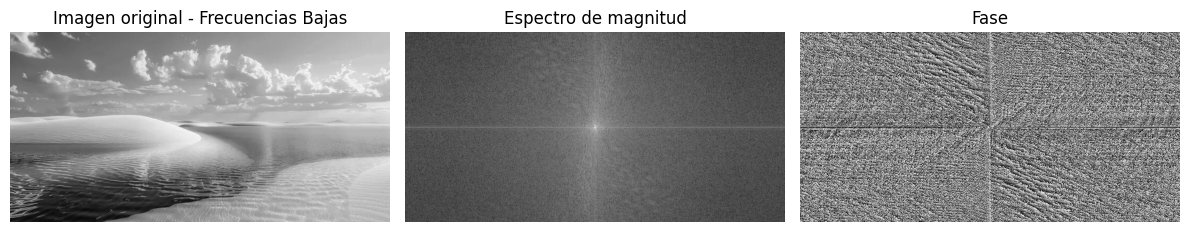

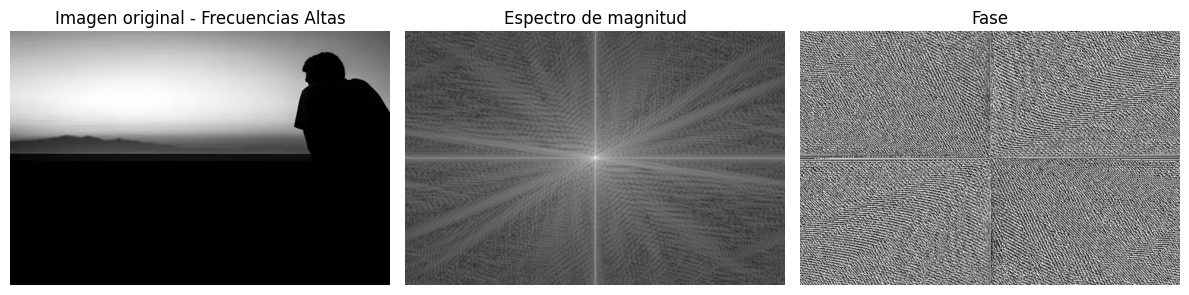

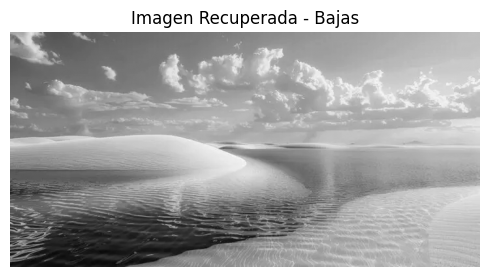

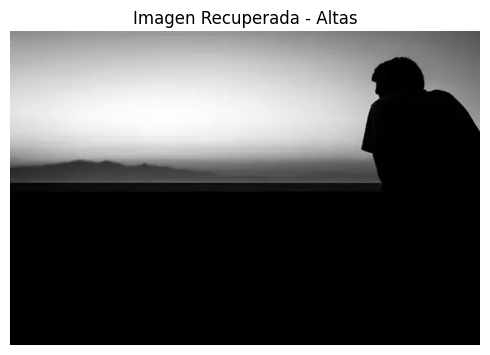

In [26]:
# Cargar imágenes
img_frecuencias_bajas = cv2.imread('baja_frec.webp', cv2.IMREAD_GRAYSCALE)
img_frecuencias_altas = cv2.imread('alta_frec.webp', cv2.IMREAD_GRAYSCALE)

# Calcular DFT centrado
dft_shift_bajas = calcular_dft_centrada(img_frecuencias_bajas)
dft_shift_altas = calcular_dft_centrada(img_frecuencias_altas)

# Mostrar espectros
mostrar_frecuencias(img_frecuencias_bajas, dft_shift_bajas, mostrar_fase=True, titulo='Frecuencias Bajas')
mostrar_frecuencias(img_frecuencias_altas, dft_shift_altas, mostrar_fase=True, titulo='Frecuencias Altas')

# Reconstrucción inversa
img_recuperada_bajas = reconstruir_imagen_idft(dft_shift_bajas, mostrar=True, titulo='Imagen Recuperada - Bajas')
img_recuperada_altas = reconstruir_imagen_idft(dft_shift_altas, mostrar=True, titulo='Imagen Recuperada - Altas')




**(a) ¿Como se visualiza la diferencia entre las frecuencias altas y bajas en una imagen? Ejercicio sugerido: Aplicar la Transformada de Fourier (DFT) y mostrar la magnitud del espectro centrado con fftshift.**

Se puede obervar una clara diferencia entre las imagenes posteriormente usadas en el dominio frecuencial. Por un lado, la imagen del bosque posee transiciones de colores mas suaves y no hay cambios o lineas tan marcas dentro de la imagen (las lineas que mas destacan son los troncos de los arboles). 

Esto se ve representado en el dominio frecuencial medinte una acumulacion de las frecuencias bajas en el centro de la imagen. Por el otro lado, en la otra imagen se puede apreciar que tiene muchas frecuencias altas ya que la imagen del paisaje tiene grandes lineas y bordes que marcan un cambio abrupto en el color de la imagen. Esto se ve representado en el espectro frecuencial como unos rayos o lineas que no se encuentran tan centrados en la region central de la representacion de las magnitudes frecuencias.  

**(b) ¿Que ocurre si eliminamos las componentes de alta frecuencia de una imagen? ¿Y si eliminamos
las de baja frecuencia? Ejercicio sugerido: Aplicar filtros pasa bajos y pasa altos en el dominio
de la frecuencia y reconstruir la imagen con la transformada inversa.**

Al eliminar las componentes de alta frecuencia provocamos que la imagen se vuelva mas "suave" en el sentido de que se empizan a distorsionar algunos bordes o detalles mas finos de la imagen ya que estos representan los cambios mas bruscos dentro de la imagen. Generalmente esto se hace cuando se quiere crear un efecto de desenfoque, se quiere reducir el ruido o se quiere realizar una compresion de la imagen.

Por el otro lado, si eliminamos las frecuencias bajas de la imagen se van a mostrar principalmente los bordes y contornos de la misma con y sacando los colores dentro de los objetos. Se usa principalmente para marcar bordes o detalles dentro de la imagen.

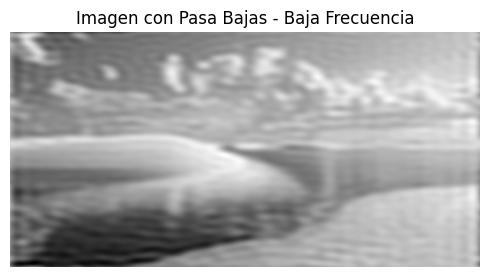

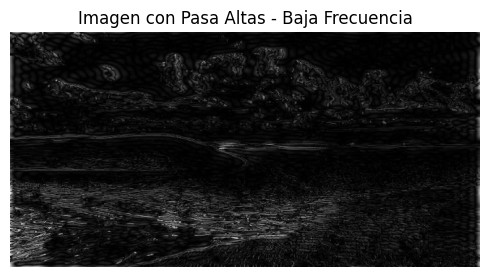

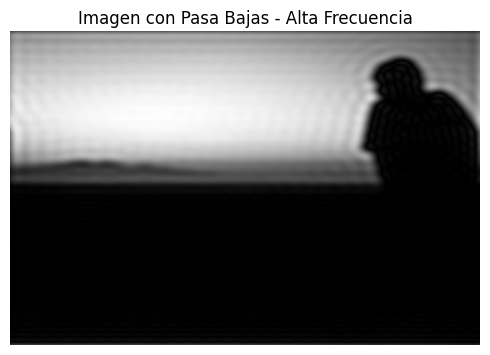

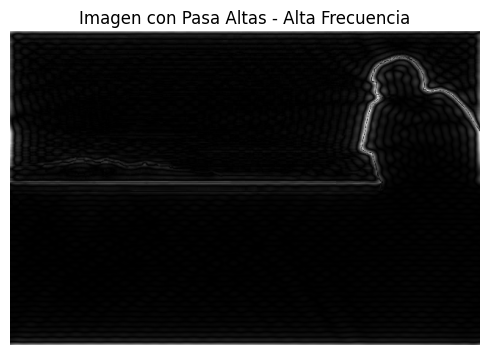

In [28]:
def crear_mascara_frecuencia(shape, radio, tipo='pasa_bajas'):
    filas, columnas = shape
    centro_fila, centro_columna = filas // 2, columnas // 2

    Y, X = np.ogrid[:filas, :columnas]
    distancia = np.sqrt((X - centro_columna)**2 + (Y - centro_fila)**2)

    if tipo == 'pasa_bajas':
        mascara = distancia <= radio
    elif tipo == 'pasa_altas':
        mascara = distancia > radio
    else:
        raise ValueError("Tipo de filtro debe ser 'pasa_bajas' o 'pasa_altas'")

    # Repetimos la máscara para 2 canales (real e imaginario)
    return np.repeat(mascara[:, :, np.newaxis], 2, axis=2).astype(np.float32)

# 1. Cargar imagen en escala de grises
img_baja_frec = cv2.imread('baja_frec.webp', cv2.IMREAD_GRAYSCALE)
img_alta_frec = cv2.imread('alta_frec.webp', cv2.IMREAD_GRAYSCALE)

# 2. Obtener el DFT centrado
dft_shift_bajas = calcular_dft_centrada(img_baja_frec)
dft_shift_altas = calcular_dft_centrada(img_alta_frec)

# 3. Crear máscaras para filtros
radio = 30  # Radio del filtro en píxeles
mascara_pasa_bajas_frecB = crear_mascara_frecuencia(img_baja_frec.shape, radio, tipo='pasa_bajas')
mascara_pasa_altas_frecB = crear_mascara_frecuencia(img_baja_frec.shape, radio, tipo='pasa_altas')
mascara_pasa_bajas_frecA = crear_mascara_frecuencia(img_alta_frec.shape, radio, tipo='pasa_bajas')
mascara_pasa_altas_frecA = crear_mascara_frecuencia(img_alta_frec.shape, radio, tipo='pasa_altas')

# 4. Aplicar filtros en frecuencia
dft_bajas_frecB = dft_shift_bajas * mascara_pasa_bajas_frecB
dft_altas_frecB = dft_shift_bajas * mascara_pasa_altas_frecB
dft_bajas_frecA = dft_shift_altas * mascara_pasa_bajas_frecA
dft_altas_frecA = dft_shift_altas * mascara_pasa_altas_frecA


# 5. Reconstrucción en el dominio espacial
img_bajas = reconstruir_imagen_idft(dft_bajas_frecB, mostrar=True, titulo='Imagen con Pasa Bajas - Baja Frecuencia')
img_altas = reconstruir_imagen_idft(dft_altas_frecB, mostrar=True, titulo='Imagen con Pasa Altas - Baja Frecuencia')
img_bajas_frecA = reconstruir_imagen_idft(dft_bajas_frecA, mostrar=True, titulo='Imagen con Pasa Bajas - Alta Frecuencia')
img_altas_frecA = reconstruir_imagen_idft(dft_altas_frecA, mostrar=True, titulo='Imagen con Pasa Altas - Alta Frecuencia')



**(c) ¿Que representa la fase de la transformada de Fourier de una imagen? ¿Que ocurre si se conserva
solo la fase o solo la magnitud? Ejercicio sugerido: Reconstruir una imagen usando solo la
magnitud y fase de otra imagen, intercambiar fase y magnitud entre dos imagenes distintas.**

La fase es la encargad de codificar la localizacion espacial de los distintos objetos dentro de la imagen, que con ayuda de la magnitud, forman a la imagen final. A la hora de reconstruir una imagen solo con la fase se puede observar que la mayoria de las formas, contornos y bordes se mantienen y se puede observar cierta semenjanza con la imagen original pero con los colores y tonalidades totalmente alterados. Cuando reconstruimos utilizando solo la magnitud la reconstruccion es una imagen totalmente lisa y sin color.

Cuando realizamos el experimento de intercambiar la fase y magnitud de 2 imagenes obtenemos que cuando mantenemos la magnitud pero cambiamos la fase, la imagen resultante tendra los colores, intensidades y texturas de originales pero tomando las formas y contornos de la segunda imagen. Cuando hacemos el caso contrario y mantenemos la fase e intercambiamos la magnitud se mantienen a grandes rasgos los contornos y detalles pero los colores y tonalidades se ven alterados. 

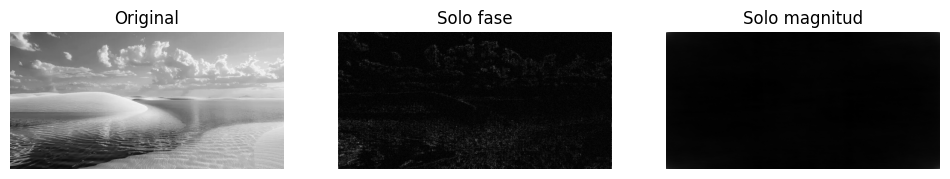

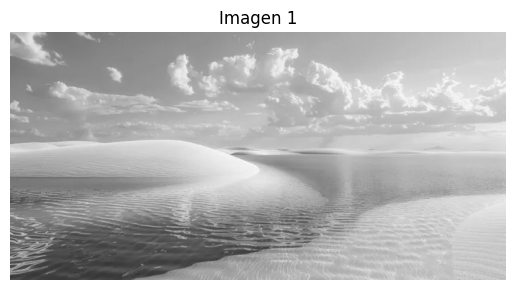

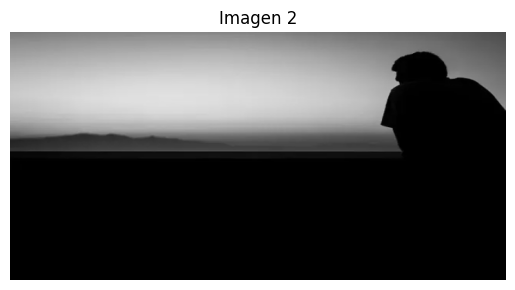

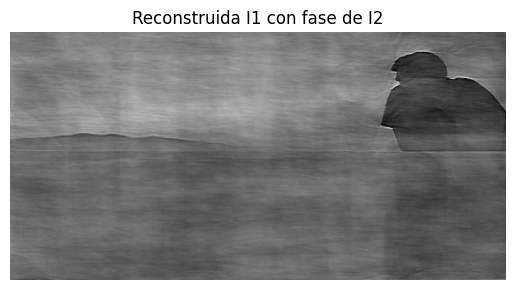

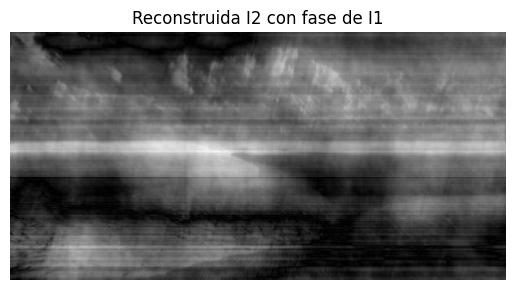

In [33]:
def dft_components(img):
    # 1) DFT
    dft = cv2.dft(np.float32(img), flags=cv2.DFT_COMPLEX_OUTPUT)
    dft_shift = np.fft.fftshift(dft)
    # 2) magnitud y fase
    real, imag = dft_shift[:,:,0], dft_shift[:,:,1]
    magnitude = np.sqrt(real**2 + imag**2)
    phase     = np.arctan2(imag, real)
    return magnitude, phase

def idft_from_components(magnitude, phase):
    # 1) recomponer complejo y aplicar ifftshift
    complex_spec = magnitude * np.exp(1j * phase)
    # expandir a par de canales
    real = np.real(complex_spec)
    imag = np.imag(complex_spec)
    combined = np.stack([real, imag], axis=-1)
    shifted  = np.fft.ifftshift(combined)
    # 2) IDFT
    img_back = cv2.idft(shifted)
    img_back = cv2.magnitude(img_back[:,:,0], img_back[:,:,1])
    # normalizar
    img_back = cv2.normalize(img_back, None, 0, 255, cv2.NORM_MINMAX)
    return np.uint8(img_back)

# Cargar dos imágenes
I1 = cv2.imread('baja_frec.webp', cv2.IMREAD_GRAYSCALE)
I2 = cv2.imread('alta_frec.webp', cv2.IMREAD_GRAYSCALE)

# Deben tener el mismo tamaño
I2 = cv2.resize(I2, (I1.shape[1], I1.shape[0]))

dft = cv2.dft(np.float32(I1), flags=cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

# Obtener magnitud y fase
real, imag = dft_shift[:, :, 0], dft_shift[:, :, 1]
magnitude = np.sqrt(real**2 + imag**2)
phase = np.arctan2(imag, real)

# === Solo FASE ===
# Usamos magnitud uniforme (todas las frecuencias con igual peso)
mag_uniforme = np.ones_like(magnitude)
recon_fase = idft_from_components(mag_uniforme, phase)

# === Solo MAGNITUD ===
# Usamos fase nula (todos los vectores alineados)
fase_nula = np.zeros_like(phase)
recon_magnitud = idft_from_components(magnitude, fase_nula)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(I1, cmap='gray'), plt.title("Original"), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(recon_fase, cmap='gray'), plt.title("Solo fase"), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(recon_magnitud, cmap='gray'), plt.title("Solo magnitud"), plt.axis('off')
plt.show()

# Extraer componentes
A1, Phi1 = dft_components(I1)
A2, Phi2 = dft_components(I2)

# Reconstruir combinaciones
R1 = idft_from_components(A1, Phi2)  # magnitud de I1 + fase de I2
R2 = idft_from_components(A2, Phi1)  # magnitud de I2 + fase de I1

show_image(I1, 'Imagen 1')
show_image(I2, 'Imagen 2')
show_image(R1, 'Reconstruida I1 con fase de I2')
show_image(R2, 'Reconstruida I2 con fase de I1')


**(d) ¿Por que se centra la transformada de Fourier para su visualizacion? ¿Que efecto tiene? Ejercicio
sugerido: Mostrar el espectro de magnitud con y sin aplicar fftshift.**

La transformada de fourier se centra para su visualizacion ya que por defecto la implementacion de la DFT coloca las frecuencias bajas en las esquinas y las frecuencias altas en el centro. Esto no es muy intuitivo a la hora de realizar el analisis de la imagen ya que al centrar las frecuencias bajas en el centro podemos ver de forma mas rapida e intuitiva si la imagen tiene predominio de frecuencias bajas o altas. Ademas, al centrar las frecuencias bajas en el centro, se facilita la aplicacion de mascaras o efectos visuales a las imagenes.

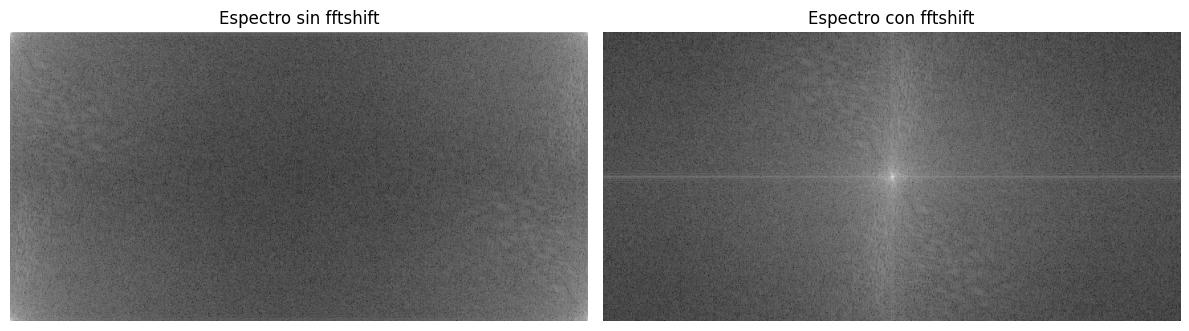

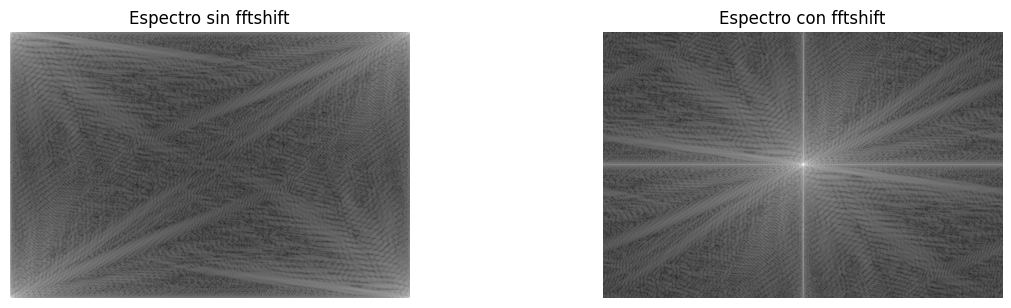

In [36]:
# 1. Cargar imagen en escala de grises
img_baja = cv2.imread('baja_frec.webp', cv2.IMREAD_GRAYSCALE)
img_alta = cv2.imread('alta_frec.webp', cv2.IMREAD_GRAYSCALE)

# 2. Aplicar DFT
dft_baja = cv2.dft(np.float32(img_baja), flags=cv2.DFT_COMPLEX_OUTPUT)
dft_alta = cv2.dft(np.float32(img_alta), flags=cv2.DFT_COMPLEX_OUTPUT)

# 3. Calcular espectro sin shift
mag_no_shift_baja = 20 * np.log1p(cv2.magnitude(dft_baja[:, :, 0], dft_baja[:, :, 1]))
mag_no_shift_alta = 20 * np.log1p(cv2.magnitude(dft_alta[:, :, 0], dft_alta[:, :, 1]))

# 4. Calcular espectro con shift
dft_shift_baja = np.fft.fftshift(dft)
mag_shift_baja = 20 * np.log1p(cv2.magnitude(dft_shift_baja[:, :, 0], dft_shift_baja[:, :, 1]))
dft_shift_alta = np.fft.fftshift(dft_alta)
mag_shift_alta = 20 * np.log1p(cv2.magnitude(dft_shift_alta[:, :, 0], dft_shift_alta[:, :, 1]))

# 5. Mostrar lado a lado
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(mag_no_shift_baja, cmap='gray')
plt.title('Espectro sin fftshift')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mag_shift_baja, cmap='gray')
plt.title('Espectro con fftshift')
plt.axis('off')

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.subplot(2, 2, 1)
plt.imshow(mag_no_shift_alta, cmap='gray')
plt.title('Espectro sin fftshift')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(mag_shift_alta, cmap='gray')
plt.title('Espectro con fftshift')
plt.axis('off')

plt.tight_layout()
plt.show()

**(e) ¿Como se comporta la transformada de Fourier ante la traslacion o rotacion de una imagen?
Ejercicio sugerido: Aplicar una traslacion o rotacion y comparar los espectros de magnitud y
fase antes y despues.**

**(f) ¿Como se refleja una estructura periodica en el dominio frecuencial? Ejercicio sugerido: Usar
imagenes sinteticas (rejillas, lıneas) y observar como se representan sus frecuencias dominantes.**


**(g) ¿Que diferencias se observan en el espectro de imagenes suaves vs. imagenes con bordes pronunciados? Ejercicio sugerido: Comparar el espectro de una imagen desenfocada vs. la original
con bordes definidos**

**(h) ¿Que ocurre si aplicamos un filtro de forma circular o rectangular en el espectro? ¿Como cambia
la imagen? Ejercicio sugerido: Implementar mascaras ideales de paso bajo y paso alto circulares
y cuadradas y observar sus efectos.**

**(i) ¿Cual es la relacion entre el patron de una imagen (orientacion, repeticion) y la simetrıa del
espectro? Ejercicio sugerido: Usar imagenes diagonales o repetitivas y analizar la simetrıa del
espectro.**


**(j) ¿Como puede usarse el dominio frecuencial para eliminar ruido periodico en una imagen? Ejercicio sugerido: Introducir ruido periodico artificialmente y diseñar un filtro para suprimirlo en
el dominio de la frecuencia**